In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

dataframe=pd.read_csv("students_adaptability_level_online_education.csv")
dataframe

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
0,Boy,21-25,University,Non Government,No,Yes,Low,Mid,Wifi,4G,3-6,No,Tab,Moderate
1,Girl,21-25,University,Non Government,No,Yes,High,Mid,Mobile Data,4G,1-3,Yes,Mobile,Moderate
2,Girl,16-20,College,Government,No,Yes,Low,Mid,Wifi,4G,1-3,No,Mobile,Moderate
3,Girl,11-15,School,Non Government,No,Yes,Low,Mid,Mobile Data,4G,1-3,No,Mobile,Moderate
4,Girl,16-20,School,Non Government,No,Yes,Low,Poor,Mobile Data,3G,0,No,Mobile,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1200,Girl,16-20,College,Non Government,No,Yes,Low,Mid,Wifi,4G,1-3,No,Mobile,Low
1201,Girl,16-20,College,Non Government,No,No,High,Mid,Wifi,4G,3-6,No,Mobile,Moderate
1202,Boy,11-15,School,Non Government,No,Yes,Low,Mid,Mobile Data,3G,1-3,No,Mobile,Moderate
1203,Girl,16-20,College,Non Government,No,No,Low,Mid,Wifi,4G,1-3,No,Mobile,Low


In [2]:
dataframe.head()

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
0,Boy,21-25,University,Non Government,No,Yes,Low,Mid,Wifi,4G,3-6,No,Tab,Moderate
1,Girl,21-25,University,Non Government,No,Yes,High,Mid,Mobile Data,4G,1-3,Yes,Mobile,Moderate
2,Girl,16-20,College,Government,No,Yes,Low,Mid,Wifi,4G,1-3,No,Mobile,Moderate
3,Girl,11-15,School,Non Government,No,Yes,Low,Mid,Mobile Data,4G,1-3,No,Mobile,Moderate
4,Girl,16-20,School,Non Government,No,Yes,Low,Poor,Mobile Data,3G,0,No,Mobile,Low


In [4]:
dataframe.sample(10)

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
320,Boy,11-15,School,Non Government,No,Yes,Low,Rich,Mobile Data,3G,1-3,No,Mobile,Moderate
356,Boy,16-20,College,Government,Yes,Yes,Low,Mid,Mobile Data,4G,1-3,No,Mobile,Moderate
485,Boy,16-20,School,Government,No,No,Low,Mid,Wifi,4G,1-3,No,Mobile,Moderate
670,Girl,16-20,College,Non Government,No,No,Low,Mid,Wifi,4G,1-3,No,Mobile,Low
310,Girl,1-5,School,Non Government,No,Yes,Low,Poor,Mobile Data,4G,1-3,No,Mobile,Moderate
4,Girl,16-20,School,Non Government,No,Yes,Low,Poor,Mobile Data,3G,0,No,Mobile,Low
401,Boy,16-20,College,Government,No,Yes,Low,Mid,Wifi,3G,1-3,Yes,Mobile,Moderate
447,Girl,21-25,University,Non Government,No,Yes,Low,Mid,Wifi,3G,1-3,Yes,Mobile,High
585,Girl,21-25,University,Non Government,Yes,No,High,Poor,Wifi,2G,3-6,Yes,Tab,Low
933,Boy,21-25,University,Non Government,Yes,Yes,High,Poor,Wifi,3G,3-6,No,Computer,Moderate


In [5]:
dataframe.describe()

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
count,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205
unique,2,6,3,2,2,2,2,3,2,3,3,2,3,3
top,Boy,21-25,School,Non Government,No,Yes,Low,Mid,Mobile Data,4G,1-3,No,Mobile,Moderate
freq,663,374,530,823,901,935,1004,878,695,775,840,995,1013,625


In [3]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Gender               1205 non-null   object
 1   Age                  1205 non-null   object
 2   Education Level      1205 non-null   object
 3   Institution Type     1205 non-null   object
 4   IT Student           1205 non-null   object
 5   Location             1205 non-null   object
 6   Load-shedding        1205 non-null   object
 7   Financial Condition  1205 non-null   object
 8   Internet Type        1205 non-null   object
 9   Network Type         1205 non-null   object
 10  Class Duration       1205 non-null   object
 11  Self Lms             1205 non-null   object
 12  Device               1205 non-null   object
 13  Adaptivity Level     1205 non-null   object
dtypes: object(14)
memory usage: 131.9+ KB


In [4]:
for i in dataframe.columns:
    print(i, ":", dataframe[i].unique().tolist())

Gender : ['Boy', 'Girl']
Age : ['21-25', '16-20', '11-15', '26-30', '6-10', '1-5']
Education Level : ['University', 'College', 'School']
Institution Type : ['Non Government', 'Government']
IT Student : ['No', 'Yes']
Location : ['Yes', 'No']
Load-shedding : ['Low', 'High']
Financial Condition : ['Mid', 'Poor', 'Rich']
Internet Type : ['Wifi', 'Mobile Data']
Network Type : ['4G', '3G', '2G']
Class Duration : ['3-6', '1-3', '0']
Self Lms : ['No', 'Yes']
Device : ['Tab', 'Mobile', 'Computer']
Adaptivity Level : ['Moderate', 'Low', 'High']


In [5]:
# numerical and categorical columns
numerical_features = [feature for feature in dataframe.columns if dataframe[feature].dtype != 'O']
categorical_features = [feature for feature in dataframe.columns if dataframe[feature].dtype == 'O']

print('We have {} numerical features : {}'.format(len(numerical_features), numerical_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 0 numerical features : []

We have 14 categorical features : ['Gender', 'Age', 'Education Level', 'Institution Type', 'IT Student', 'Location', 'Load-shedding', 'Financial Condition', 'Internet Type', 'Network Type', 'Class Duration', 'Self Lms', 'Device', 'Adaptivity Level']


In [17]:
dataframe.shape

(1205, 14)

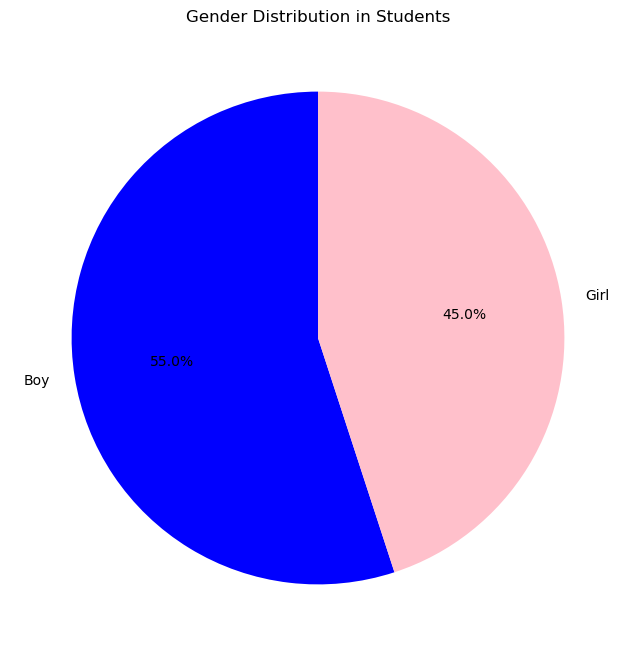

In [6]:
#Which gender has high ratio in percentage?
import matplotlib.pyplot as plt

#Count the occurrences of each gender
gender_count=dataframe['Gender'].value_counts()

#Convert to percentage
gender_percentage=(gender_count/gender_count.sum())*100

#Pie chart
plt.figure(figsize=(8, 8))
plt.pie(gender_percentage, labels=gender_percentage.index, autopct='%1.1f%%', startangle=90, colors=['blue', 'pink'])
plt.title('Gender Distribution in Students')
plt.show()

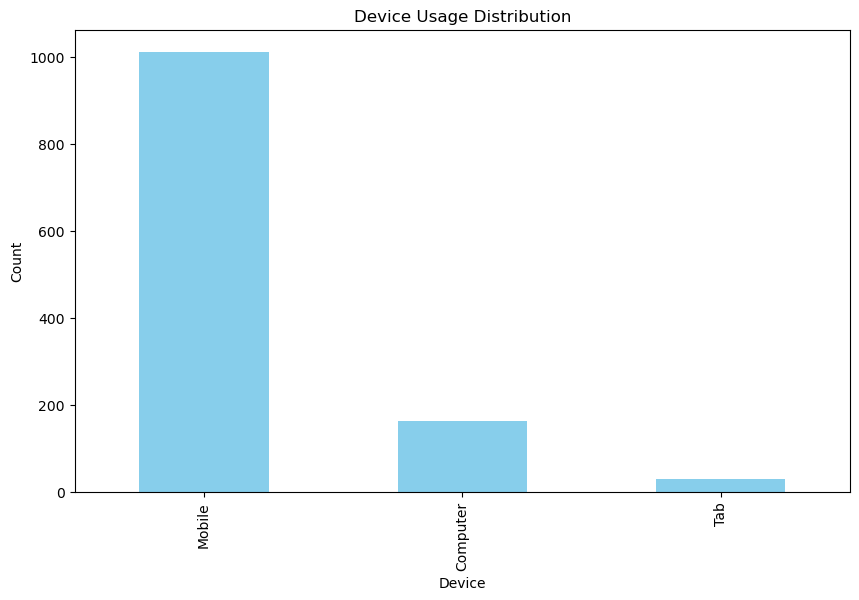

The device with the highest usage is: Mobile


In [23]:
#Which device is more reliable in using online education?
device_count=dataframe['Device'].value_counts()

# Plot a bar chart to visualize device usage
plt.figure(figsize=(10, 6))
device_count.plot(kind='bar', color='skyblue')
plt.title('Device Usage Distribution')
plt.xlabel('Device')
plt.ylabel('Count')
plt.show()

# Display the device with the highest usage
highest_usage_device = device_count.idxmax()
print(f"The device with the highest usage is: {highest_usage_device}")

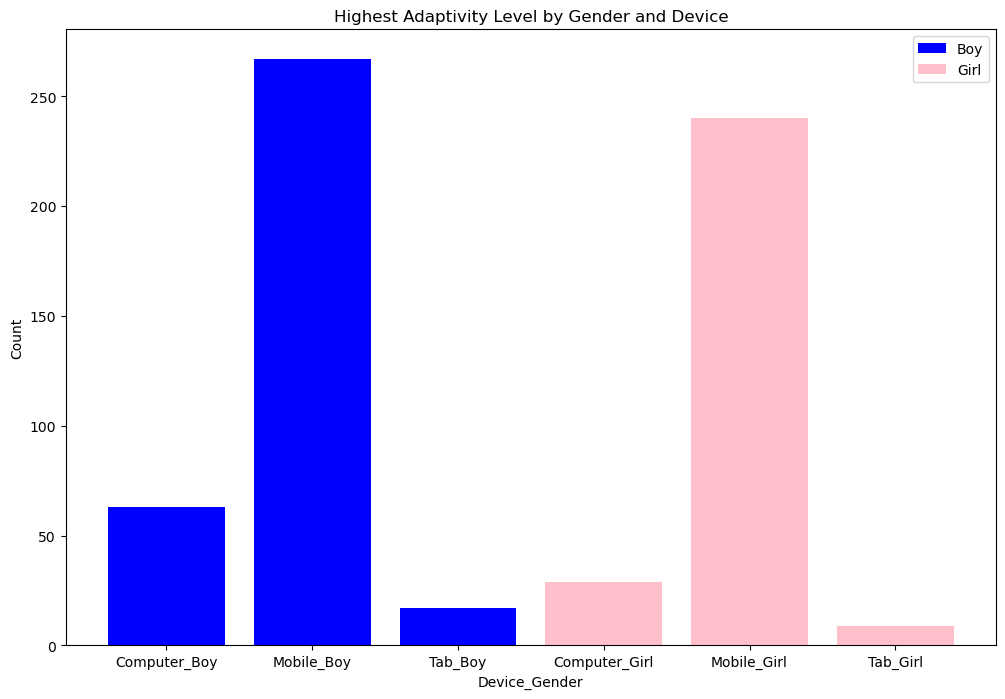

In [28]:
# Count the occurrences of each combination of 'Gender', 'Device', and 'Adaptivity Level'
gender_device_adaptivity_counts = dataframe.groupby(['Gender', 'Device', 'Adaptivity Level']).size().reset_index(name='Count')

# Find the row with the highest count (highest adaptivity level) for each gender and device
idx = gender_device_adaptivity_counts.groupby(['Gender', 'Device'])['Count'].idxmax()
highest_adaptivity_levels = gender_device_adaptivity_counts.loc[idx]

# Plot a bar chart to visualize the highest adaptivity levels for each gender and device
plt.figure(figsize=(12, 8))
for gender in highest_adaptivity_levels['Gender'].unique():
    data = highest_adaptivity_levels[highest_adaptivity_levels['Gender'] == gender]
    color = 'blue' if gender == 'Boy' else 'pink'
    plt.bar(data['Device'] + '_' + gender, data['Count'], label=gender, color=color)

plt.title('Highest Adaptivity Level by Gender and Device')
plt.xlabel('Device_Gender')
plt.ylabel('Count')
plt.legend()
plt.show()

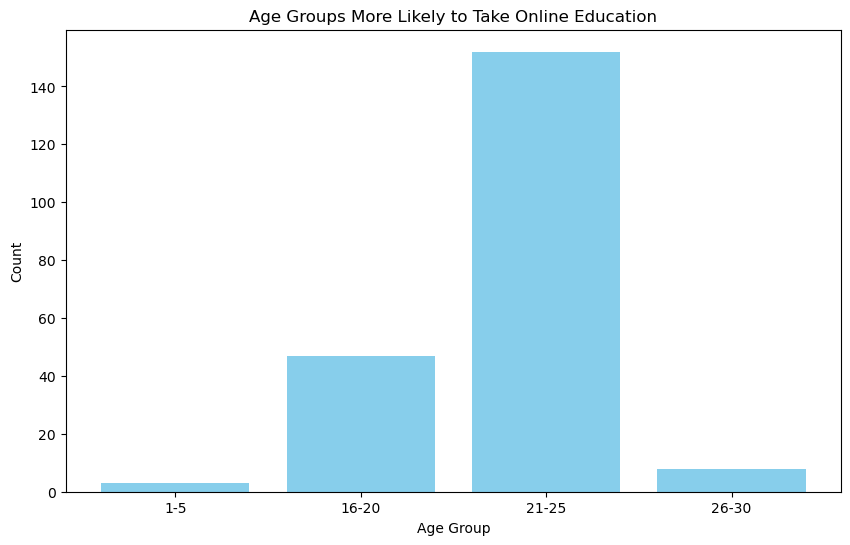

In [30]:
# Count the occurrences of each combination of 'Age' and 'Self Lms'
age_self_lms_counts = dataframe.groupby(['Age', 'Self Lms']).size().reset_index(name='Count')

# Filter for rows where 'Self Lms' is 'Yes' (indicating online education)
online_education_counts = age_self_lms_counts[age_self_lms_counts['Self Lms'] == 'Yes']

# Plot a bar chart to visualize the age groups more likely to take online education
plt.figure(figsize=(10, 6))
plt.bar(online_education_counts['Age'], online_education_counts['Count'], color='skyblue')
plt.title('Age Groups More Likely to Take Online Education')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

In [8]:
#According to financial condition, how many students are there who are IT students?
it_student=dataframe[dataframe['IT Student']=='Yes']

#Count the occurrences of each combination of 'Financial Condition' and 'IT Student'
financial_condition_count=it_student.groupby('Financial Condition').size().reset_index(name='Number of IT student')

#Display the result

print("Number of IT Students According to Financial Condition:")
print(financial_condition_count.to_string(index=False, justify='center'))

Number of IT Students According to Financial Condition:
Financial Condition  Number of IT student
         Mid                 233         
        Poor                  46         
        Rich                  25         


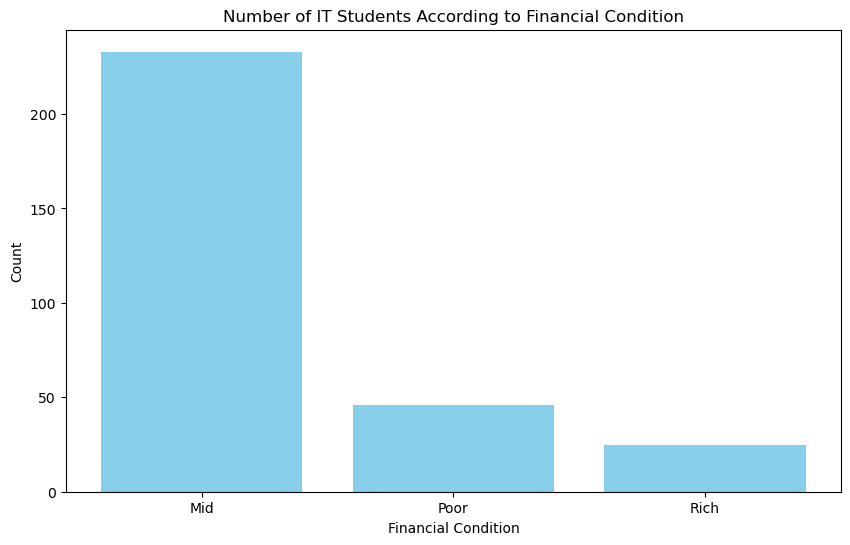

In [9]:
# Plot a bar chart to visualize the number of IT students according to financial condition
plt.figure(figsize=(10, 6))
plt.bar(financial_condition_count['Financial Condition'], financial_condition_count['Number of IT student'], color='skyblue')
plt.title('Number of IT Students According to Financial Condition')
plt.xlabel('Financial Condition')
plt.ylabel('Count')
plt.show()

In [11]:
#Among financial condition, which category has mostly low adaptivity level?
#Count the occurrences of each combination of 'Financial Condition' and 'Adaptivity Level
financial_adaptivity_counts = dataframe.groupby(['Financial Condition', 'Adaptivity Level']).size().reset_index(name='Count')

# Filter for rows where 'Adaptivity Level' is 'Low'
low_adaptivity_counts = financial_adaptivity_counts[financial_adaptivity_counts['Adaptivity Level'] == 'Low']

# Find the financial condition category with the most occurrences of low adaptivity level
most_low_adaptivity_condition = low_adaptivity_counts.loc[low_adaptivity_counts['Count'].idxmax()]['Financial Condition']

# Display the result
print(f"The financial condition category with mostly low adaptivity level is: {most_low_adaptivity_condition}")

The financial condition category with mostly low adaptivity level is: Mid


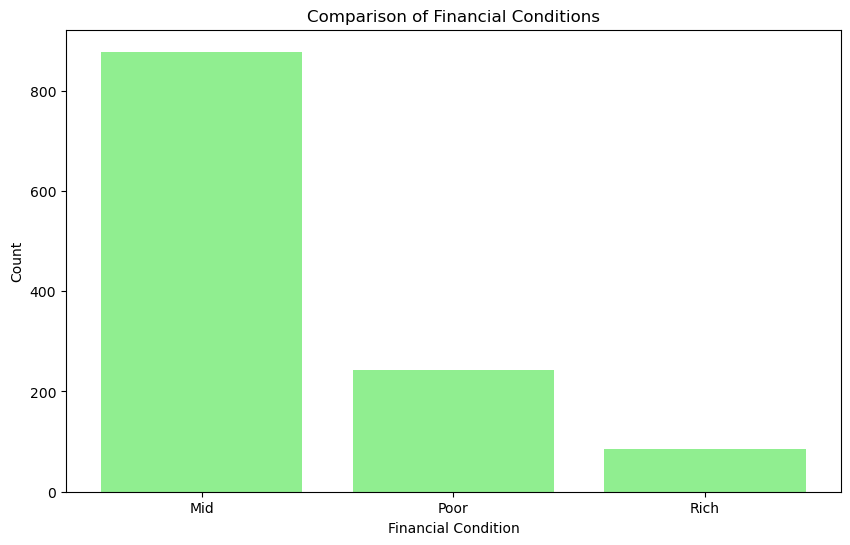

In [16]:
# Count the occurrences of each financial condition
financial_condition_counts = dataframe['Financial Condition'].value_counts().reset_index(name='Count')

# Plot a bar chart to compare financial conditions
plt.figure(figsize=(10, 6))
plt.bar(financial_condition_counts['Financial Condition'], financial_condition_counts['Count'], color='lightgreen')
plt.title('Comparison of Financial Conditions')
plt.xlabel('Financial Condition')
plt.ylabel('Count')
plt.show()

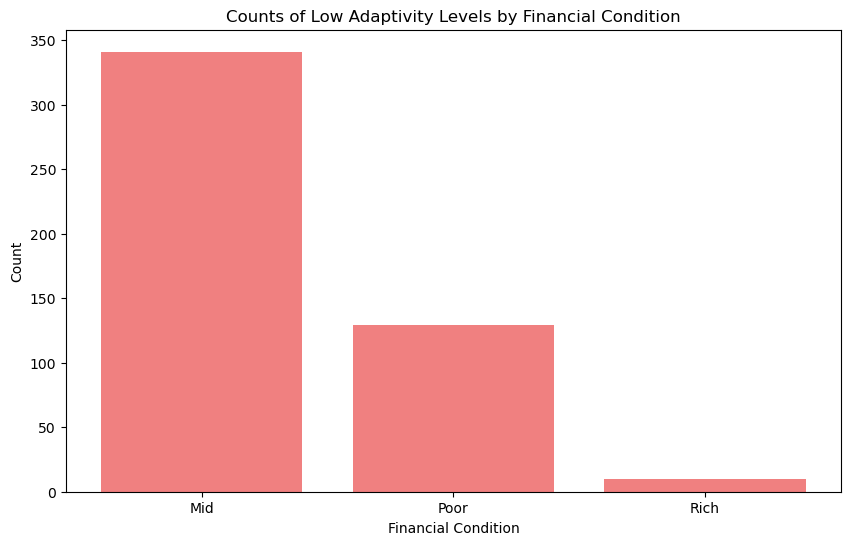

In [12]:
#Plot a bar chart to visualize the financial condition categories with counts of low adaptivity levels
plt.figure(figsize=(10, 6))
plt.bar(low_adaptivity_counts['Financial Condition'], low_adaptivity_counts['Count'], color='lightcoral')
plt.title('Counts of Low Adaptivity Levels by Financial Condition')
plt.xlabel('Financial Condition')
plt.ylabel('Count')
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

categorical_columns=['Gender', 'Age', 'Education Level', 'Institution Type', 'IT Student', 'Location', 'Load-shedding', 'Financial Condition', 'Internet Type', 'Network Type', 'Class Duration', 'Self Lms', 'Device', 'Adaptivity Level']

#Create LabelEncoder instances
label_encoder=LabelEncoder()

#Iterate through each column and apply LabelEncoder
for col in categorical_columns:
    if col in dataframe.columns:
        dataframe[col] = label_encoder.fit_transform(dataframe[col])
        
#Print
dataframe.head()

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
0,0,3,2,1,0,1,1,0,1,2,2,0,2,2
1,1,3,2,1,0,1,0,0,0,2,1,1,1,2
2,1,2,0,0,0,1,1,0,1,2,1,0,1,2
3,1,1,1,1,0,1,1,0,0,2,1,0,1,2
4,1,2,1,1,0,1,1,1,0,1,0,0,1,1


In [23]:
#Split the data
X=dataframe.drop(['Adaptivity Level'], axis=1)
y=dataframe['Adaptivity Level']

X_test, X_train, y_test, y_train=train_test_split(X, y, test_size=0.2, random_state=42)

#Display the shape of each step
print("X_test shape: ", X_test.shape)
print("X_train shape: ", X_train.shape)
print("y_test shape: ", y_test.shape)
print("y_train shape: ", y_train.shape)

X_test shape:  (964, 13)
X_train shape:  (241, 13)
y_test shape:  (964,)
y_train shape:  (241,)


In [24]:
print("X_test: ", X_test)
print("X_train: ", X_train)
print("y_test: ", y_test)
print("y_train: ", y_train)

X_test:        Gender  Age  Education Level  Institution Type  IT Student  Location  \
294        1    0                1                 0           0         1   
876        0    1                1                 1           0         1   
382        0    1                1                 1           0         1   
634        1    3                2                 0           0         1   
906        1    1                1                 0           0         1   
...      ...  ...              ...               ...         ...       ...   
1044       1    2                0                 1           0         1   
1095       1    3                2                 1           1         1   
1130       0    1                1                 1           0         1   
860        0    3                2                 1           0         1   
1126       0    3                2                 1           1         0   

      Load-shedding  Financial Condition  Internet Typ

Train Accuracy: 0.84


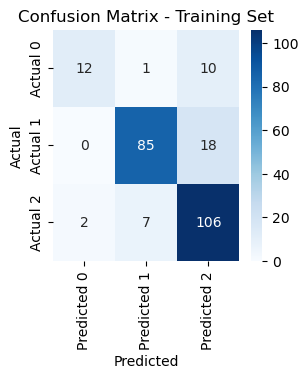

Test Accuracy: 0.75


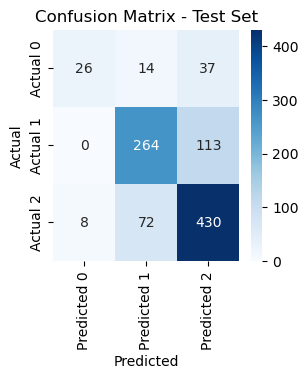

Classification Report:
              precision    recall  f1-score   support

        High       0.76      0.34      0.47        77
         Low       0.75      0.70      0.73       377
    Moderate       0.74      0.84      0.79       510

    accuracy                           0.75       964
   macro avg       0.75      0.63      0.66       964
weighted avg       0.75      0.75      0.74       964



In [38]:
#Create XGBoost model
import xgboost as xgb
from sklearn.metrics import accuracy_score

xgb_model=xgb.XGBClassifier(max_depth=5,
                       learning_rate=0.01,
                       n_estimators=200)

#Train the model on the training data
xgb_model.fit(X_train, y_train)

#Make predictions
y_pred=xgb_model.predict(X_test)

#Evaluate the accuracy of the model
xgb_accuracy=accuracy_score(y_test, y_pred)
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Train Accuracy
    y_train_pred = xgb_model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    print(f"Train Accuracy: {train_accuracy:.2f}")
    # Confusion Matrix for Training Set
    cm_train = confusion_matrix(y_train, y_train_pred)
    plt.figure(figsize=(3, 3))
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'], yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Training Set')
    plt.show()

    # Test Accuracy
    y_test_pred = xgb_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    print(f"Test Accuracy: {test_accuracy:.2f}")
    # Confusion Matrix for Test Set
    cm_test = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(3, 3))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'], yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Test Set')
    plt.show()
    
    # Classification Report
    class_report = classification_report(y_test, y_test_pred, target_names=['High', 'Low', 'Moderate'])
    print("Classification Report:")
    print(class_report)

# Evaluate and plot
evaluate_model(xgb_model, X_train, y_train, X_test, y_test)

Train Accuracy: 0.79


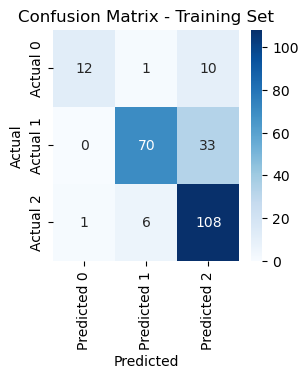

Test Accuracy: 0.70


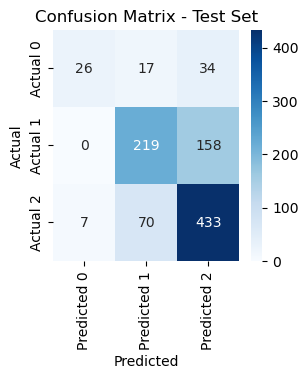

Classification Report:
              precision    recall  f1-score   support

        High       0.79      0.34      0.47        77
         Low       0.72      0.58      0.64       377
    Moderate       0.69      0.85      0.76       510

    accuracy                           0.70       964
   macro avg       0.73      0.59      0.63       964
weighted avg       0.71      0.70      0.69       964



In [36]:
import catboost

# Create CatBoost model
cat_model = catboost.CatBoostClassifier(iterations=200,
                                        learning_rate=0.01,
                                        depth=5,
                                        loss_function='MultiClass',
                                       verbose=False)

# Train the model on the training data
cat_model.fit(X_train, y_train)

# Make predictions
y_cat_pred = cat_model.predict(X_test)

# Evaluate the accuracy of the model
cat_accuracy = accuracy_score(y_test, y_cat_pred)

# Function to evaluate and plot CatBoost model
def evaluate_cat_model(model, X_train, y_train, X_test, y_test):
    # Train Accuracy
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    print(f"Train Accuracy: {train_accuracy:.2f}")

    # Confusion Matrix for Training Set
    cm_train = confusion_matrix(y_train, y_train_pred)
    plt.figure(figsize=(3, 3))
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'], yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Training Set')
    plt.show()

    # Test Accuracy
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    print(f"Test Accuracy: {test_accuracy:.2f}")

    # Confusion Matrix for Test Set
    cm_test = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(3, 3))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'], yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Test Set')
    plt.show()

    # Classification Report
    class_report = classification_report(y_test, y_test_pred, target_names=['High', 'Low', 'Moderate'])
    print("Classification Report:")
    print(class_report)

# Evaluate and plot CatBoost model
evaluate_cat_model(cat_model, X_train, y_train, X_test, y_test)

In [40]:
!pip install lightgbm

  Obtaining dependency information for lightgbm from https://files.pythonhosted.org/packages/74/02/5ad29a2a3d193a87d5a05fb7fd3b4e30b8eb6db7a9ddbe193beb7053978f/lightgbm-4.2.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.3 MB 487.6 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.3 MB 837.8 kB/s eta 0:00:02
   ---- ----------------------------------- 0.2/1.3 MB 913.1 kB/s eta 0:00:02
   ------- -------------------------------- 0.3/1.3 MB 1.3 MB/s eta 0:00:01
   ------------ --------------------------- 0.4/1.3 MB 1.6 MB/s eta 0:00:01
   ---------------- ----------------------- 0.6/1.3 MB 1.8 MB/s eta 0:00:01
   -------------------- ------------------- 0.7/1.3 MB 1.9 MB/s eta 0:00:01
   ------------------------ --------------- 0.8/

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

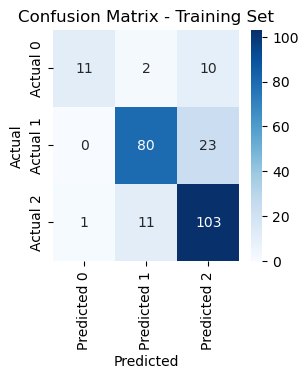

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
Test Accuracy: 0.72


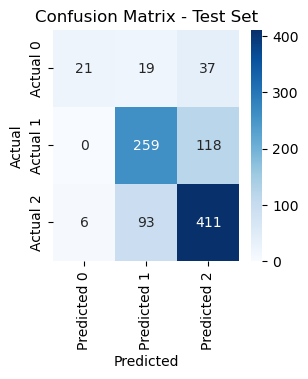

Classification Report:
              precision    recall  f1-score   support

        High       0.78      0.27      0.40        77
         Low       0.70      0.69      0.69       377
    Moderate       0.73      0.81      0.76       510

    accuracy                           0.72       964
   macro avg       0.73      0.59      0.62       964
weighted avg       0.72      0.72      0.71       964



In [46]:
import lightgbm as lgb

# Create LightGBM model
lightgbm_model = lgb.LGBMClassifier(max_depth=5, learning_rate=0.01, n_estimators=200, verbosity=0)

# Train the model on the training data
lightgbm_model.fit(X_train, y_train)

# Make predictions
y_lightgbm_pred = lightgbm_model.predict(X_test)

# Evaluate the accuracy of the LightGBM model
lightgbm_accuracy = accuracy_score(y_test, y_lightgbm_pred)

# Define the evaluate_lightgbm_model function
def evaluate_lightgbm_model(model, X_train, y_train, X_test, y_test):
    # Train Accuracy
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    print(f"Train Accuracy: {train_accuracy:.2f}")
    # Confusion Matrix for Training Set
    cm_train = confusion_matrix(y_train, y_train_pred)
    plt.figure(figsize=(3, 3))
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'], yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Training Set')
    plt.show()

    # Test Accuracy
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    print(f"Test Accuracy: {test_accuracy:.2f}")
    # Confusion Matrix for Test Set
    cm_test = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(3, 3))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'], yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Test Set')
    plt.show()
    
    # Classification Report
    class_report = classification_report(y_test, y_test_pred, target_names=['High', 'Low', 'Moderate'])
    print("Classification Report:")
    print(class_report)

# Evaluate and plot for LightGBM model
evaluate_lightgbm_model(lightgbm_model, X_train, y_train, X_test, y_test)

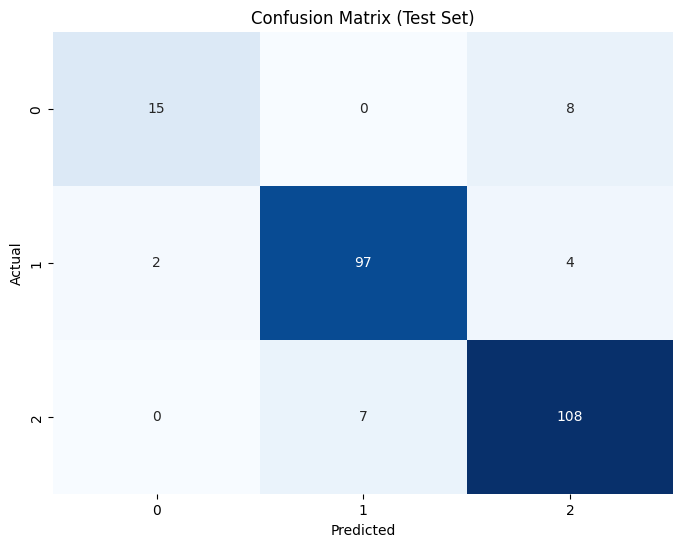

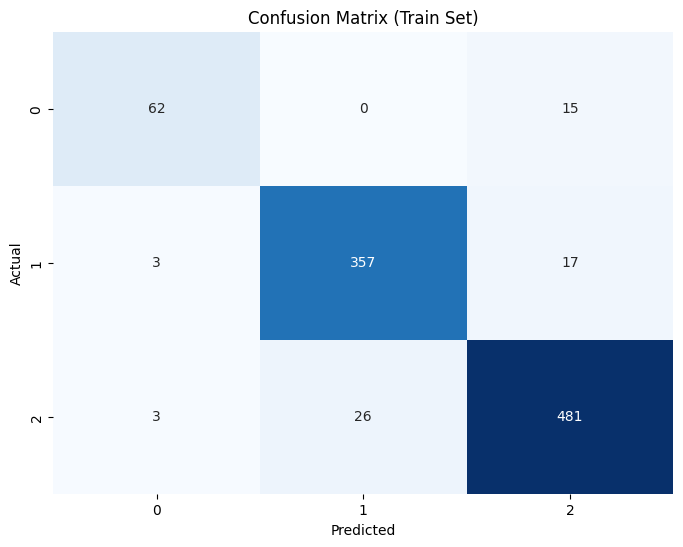


Accuracy: 0.9128630705394191
Classification Report:
               precision    recall  f1-score   support

        High       0.88      0.65      0.75        23
         Low       0.93      0.94      0.94       103
    Moderate       0.90      0.94      0.92       115

    accuracy                           0.91       241
   macro avg       0.91      0.84      0.87       241
weighted avg       0.91      0.91      0.91       241



In [1]:
#FastTree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load the dataset
file_path = 'students_adaptability_level_online_education.csv'
df = pd.read_csv(file_path)

# Identify the target variable and features
X = df.drop('Adaptivity Level', axis=1)  # Features
y = df['Adaptivity Level']  # Target variable

# Handle categorical features using one-hot encoding
categorical_cols = [col for col in X.columns if X[col].dtype == 'object']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(), categorical_cols)],
    remainder='passthrough'
)

X = preprocessor.fit_transform(X)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the FastTree model
model = HistGradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Confusion matrix for test set
conf_matrix_test = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Confusion matrix for train set
y_pred_train = model.predict(X_train)
conf_matrix_train = confusion_matrix(y_train, y_pred_train)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Train Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print the results
print(f'\nAccuracy: {accuracy}')
print('Classification Report:\n', classification_rep)


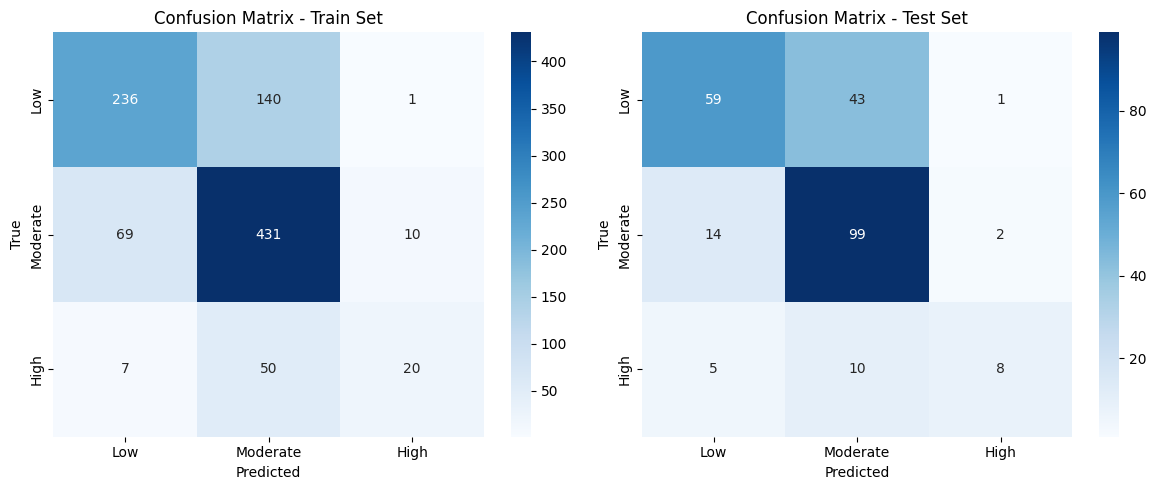


Accuracy: 0.6887966804979253
Classification Report:
               precision    recall  f1-score   support

           1       0.76      0.57      0.65       103
           2       0.65      0.86      0.74       115
           3       0.73      0.35      0.47        23

    accuracy                           0.69       241
   macro avg       0.71      0.59      0.62       241
weighted avg       0.70      0.69      0.68       241



In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'students_adaptability_level_online_education.csv'
df = pd.read_csv(file_path)

# Check for duplicate rows
duplicates = df[df.duplicated()]

# Remove duplicate rows
unique_df = df.drop_duplicates()

# Map categorical values to numerical values for 'Adaptivity Level'
df['Adaptivity Level'] = df['Adaptivity Level'].map({'Low': 1, 'Moderate': 2, 'High': 3})

# Define features (X) and target variable (y)
X = df.drop('Adaptivity Level', axis=1)
y = df['Adaptivity Level']

# Convert categorical variables to dummy/indicator variables
X = pd.get_dummies(X, drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle NaN values in the target variable
y_test = y_test.dropna()

# Initialize and fit the model with L1 regularization
model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# Predict the labels
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

# Generate confusion matrices
cm_test = confusion_matrix(y_test, y_pred_test)
cm_train = confusion_matrix(y_train, y_pred_train)

# Plot the confusion matrices using seaborn
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Moderate', 'High'], yticklabels=['Low', 'Moderate', 'High'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Train Set')

plt.subplot(1, 2, 2)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Moderate', 'High'], yticklabels=['Low', 'Moderate', 'High'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test Set')

plt.tight_layout()
plt.show()

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_test)
classification_rep = classification_report(y_test, y_pred_test)

# Print the results
print(f'\nAccuracy: {accuracy}')
print('Classification Report:\n', classification_rep)


In [53]:
models = ["XGBoost", "Catboost", "LightGBM"]
accuracies = [xgb_accuracy, cat_accuracy, lightgbm_accuracy]

# Create a DataFrame
comparison_df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})

print(comparison_df)


      Model  Accuracy
0   XGBoost  0.746888
1  Catboost  0.703320
2  LightGBM  0.716805


In [7]:
import pandas as pd

# Accuracy scores
xgb_accuracy = 0.746888
cat_accuracy = 0.703320
lightgbm_accuracy = 0.716805
fasttree_accuracy = 0.9128630705394191
l1_regularization_accuracy = 0.6887966804979253

# Create a DataFrame
models = ["XGBoost", "CatBoost", "LightGBM", "FastTree", "L1 Regularization"]
accuracies = [xgb_accuracy, cat_accuracy, lightgbm_accuracy, fasttree_accuracy, l1_regularization_accuracy]

comparison_df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})

# Add a column for ranking
comparison_df['Rank'] = comparison_df['Accuracy'].rank(ascending=False).astype(int)

# Sort the DataFrame by rank
comparison_df = comparison_df.sort_values(by='Rank')

# Print the updated DataFrame
print(comparison_df)


               Model  Accuracy  Rank
3           FastTree  0.912863     1
0            XGBoost  0.746888     2
2           LightGBM  0.716805     3
1           CatBoost  0.703320     4
4  L1 Regularization  0.688797     5
